# 07 — Temporal Modeling for VF Series

Test BiLSTM and Temporal Transformer on synthetic longitudinal VF data.
Key questions:
- Can the model learn progression slope from VF sequences?
- How does BiLSTM compare to Transformer on short sequences (3-10 visits)?
- How to handle variable-length sequences?

In [1]:
import sys
sys.path.insert(0, "..")

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

from src.models.backbones import VisualFieldEncoder
from src.models.temporal import BidirectionalLSTM, TemporalTransformer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## 1. Synthetic Longitudinal VF Data

In [2]:
def generate_vf_series(n_patients=500, max_visits=10, n_points=54, seed=42):
    """Generate synthetic longitudinal VF sensitivity series."""
    rng = np.random.default_rng(seed)
    
    # Progression rates (labels): dB/year
    true_rates = rng.choice([-0.2, -0.5, -1.0, -2.0, -3.0], n_patients,
                             p=[0.3, 0.25, 0.2, 0.15, 0.1])
    
    # Baseline sensitivities (normal ~28dB, reduce for glaucomatous)
    baselines = rng.normal(22, 5, (n_patients, n_points)).clip(5, 35)
    
    vf_series = np.zeros((n_patients, max_visits, n_points), dtype=np.float32)
    lengths = rng.integers(3, max_visits + 1, n_patients)
    
    for i in range(n_patients):
        for v in range(lengths[i]):
            t = v * 0.5  # 6-month intervals
            noise = rng.normal(0, 1.0, n_points)  # test-retest variability
            vf_series[i, v] = baselines[i] + true_rates[i] * t + noise
    
    # Normalize to [0, 1]
    vf_series = (vf_series.clip(-35, 35) + 35) / 70
    
    return vf_series, lengths, true_rates

vf_data, lengths, labels = generate_vf_series(n_patients=500, max_visits=10)
print(f"VF series shape: {vf_data.shape}")
print(f"Lengths: min={lengths.min()}, max={lengths.max()}, mean={lengths.mean():.1f}")
print(f"Rate distribution: {np.unique(labels, return_counts=True)}")

VF series shape: (500, 10, 54)
Lengths: min=3, max=10, mean=6.5
Rate distribution: (array([-3. , -2. , -1. , -0.5, -0.2]), array([ 45,  79, 109, 114, 153]))


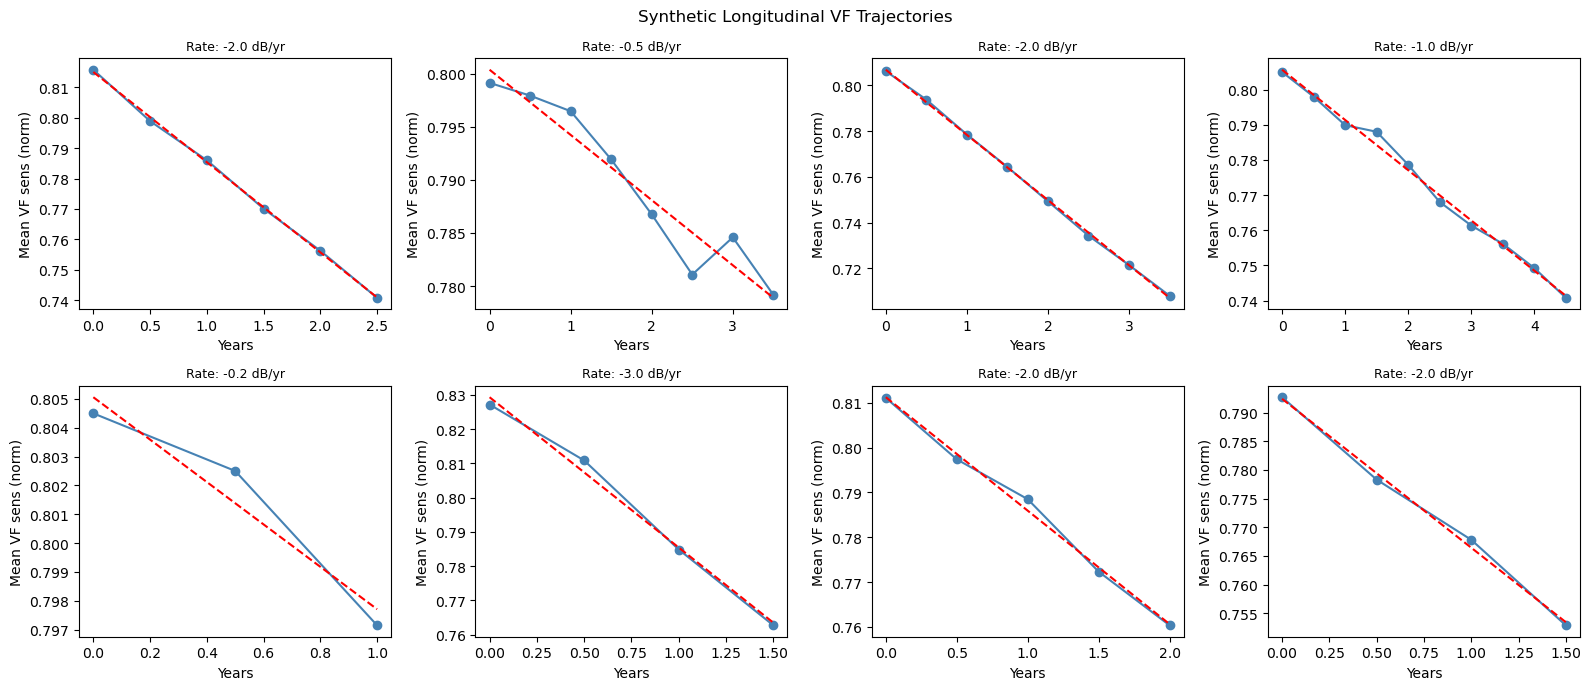

In [3]:
# Visualize sample trajectories
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, idx in zip(axes.flat, range(8)):
    n_v = lengths[idx]
    mean_sensitivity = vf_data[idx, :n_v].mean(axis=1)  # mean across 54 points per visit
    visits = np.arange(n_v) * 0.5
    ax.plot(visits, mean_sensitivity, "o-", color="steelblue", ms=6)
    slope = np.polyfit(visits, mean_sensitivity, 1)
    ax.plot(visits, np.polyval(slope, visits), "r--", lw=1.5)
    ax.set_title(f"Rate: {labels[idx]:.1f} dB/yr", fontsize=9)
    ax.set_xlabel("Years"); ax.set_ylabel("Mean VF sens (norm)")
plt.suptitle("Synthetic Longitudinal VF Trajectories")
plt.tight_layout()
plt.savefig("../reports/temporal_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Dataset and DataLoader

In [4]:
# Split data
n = len(vf_data)
n_train = int(0.7 * n)
n_val   = int(0.15 * n)

X_train = torch.tensor(vf_data[:n_train], dtype=torch.float32)
L_train = torch.tensor(lengths[:n_train], dtype=torch.long)
Y_train = torch.tensor(labels[:n_train], dtype=torch.float32)

X_val = torch.tensor(vf_data[n_train:n_train+n_val], dtype=torch.float32)
L_val = torch.tensor(lengths[n_train:n_train+n_val], dtype=torch.long)
Y_val = torch.tensor(labels[n_train:n_train+n_val], dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train, L_train, Y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, L_val, Y_val), batch_size=32, shuffle=False)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 11, Val batches: 3


## 3. VF Encoder + BiLSTM Model

In [5]:
class VFProgressionLSTM(nn.Module):
    def __init__(self, n_points=54, hidden_dim=128, lstm_hidden=128):
        super().__init__()
        self.encoder = VisualFieldEncoder(n_points=n_points, hidden_dim=hidden_dim)
        self.lstm = BidirectionalLSTM(input_dim=hidden_dim, hidden_dim=lstm_hidden, num_layers=2)
        self.head = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 64),
            nn.GELU(),
            nn.Linear(64, 1),
        )
    
    def forward(self, vf, lengths):
        enc = self.encoder(vf)            # (B, T, hidden_dim)
        _, last = self.lstm(enc, lengths) # (B, lstm_hidden*2)
        return self.head(last).squeeze(1) # (B,)

lstm_model = VFProgressionLSTM().to(device)
print(f"BiLSTM model params: {sum(p.numel() for p in lstm_model.parameters()):,}")

# Quick forward check
xb, lb, yb = next(iter(train_loader))
out = lstm_model(xb.to(device), lb.to(device))
print(f"Output shape: {out.shape}, range: [{out.min():.3f}, {out.max():.3f}]")

BiLSTM model params: 700,545
Output shape: torch.Size([32]), range: [0.102, 0.116]


## 4. Training Loop

In [6]:
def train_model(model, train_loader, val_loader, n_epochs=30, lr=3e-4):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    criterion = nn.HuberLoss()
    
    train_losses, val_maes = [], []
    
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0
        for xb, lb, yb in train_loader:
            xb, lb, yb = xb.to(device), lb.to(device), yb.to(device)
            pred = model(xb, lb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        
        # Validation MAE
        model.eval()
        all_preds, all_targets = [], []
        with torch.no_grad():
            for xb, lb, yb in val_loader:
                pred = model(xb.to(device), lb.to(device))
                all_preds.append(pred.cpu())
                all_targets.append(yb)
        
        preds_np = torch.cat(all_preds).numpy()
        targets_np = torch.cat(all_targets).numpy()
        val_mae = np.abs(preds_np - targets_np).mean()
        
        train_losses.append(epoch_loss / len(train_loader))
        val_maes.append(val_mae)
        scheduler.step()
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:3d}: loss={train_losses[-1]:.4f}, val_MAE={val_mae:.4f} dB/yr")
    
    return train_losses, val_maes, preds_np, targets_np

print("Training BiLSTM...")
lstm_losses, lstm_maes, lstm_preds, lstm_targets = train_model(lstm_model, train_loader, val_loader)

Training BiLSTM...
Epoch   5: loss=0.3355, val_MAE=0.7506 dB/yr
Epoch  10: loss=0.3337, val_MAE=0.7513 dB/yr
Epoch  15: loss=0.3340, val_MAE=0.7508 dB/yr
Epoch  20: loss=0.3347, val_MAE=0.7514 dB/yr
Epoch  25: loss=0.3343, val_MAE=0.7511 dB/yr
Epoch  30: loss=0.3347, val_MAE=0.7511 dB/yr


## 5. VF Encoder + Temporal Transformer

In [7]:
class VFProgressionTransformer(nn.Module):
    def __init__(self, n_points=54, hidden_dim=128, d_model=128, nhead=4, num_layers=2):
        super().__init__()
        self.encoder = VisualFieldEncoder(n_points=n_points, hidden_dim=hidden_dim)
        self.transformer = TemporalTransformer(
            input_dim=hidden_dim, d_model=d_model, nhead=nhead, num_layers=num_layers
        )
        self.head = nn.Sequential(nn.Linear(d_model, 64), nn.GELU(), nn.Linear(64, 1))
    
    def forward(self, vf, lengths):
        B, T, N = vf.shape
        # Create padding mask
        mask = torch.arange(T, device=vf.device).unsqueeze(0) >= lengths.unsqueeze(1)
        enc = self.encoder(vf)
        _, pooled = self.transformer(enc, mask=mask)
        return self.head(pooled).squeeze(1)

transformer_model = VFProgressionTransformer().to(device)
print(f"Transformer params: {sum(p.numel() for p in transformer_model.parameters()):,}")

print("Training Transformer...")
trans_losses, trans_maes, trans_preds, trans_targets = train_model(
    transformer_model, train_loader, val_loader
)

Transformer params: 448,001
Training Transformer...


/Users/taiaburrahman/Desktop/git/glam/notebooks/../src/models/temporal.py:89: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Epoch   5: loss=0.3348, val_MAE=0.7574 dB/yr
Epoch  10: loss=0.3394, val_MAE=0.7569 dB/yr
Epoch  15: loss=0.3319, val_MAE=0.7589 dB/yr
Epoch  20: loss=0.3251, val_MAE=0.7581 dB/yr
Epoch  25: loss=0.3196, val_MAE=0.7605 dB/yr
Epoch  30: loss=0.3170, val_MAE=0.7575 dB/yr


## 6. Compare: BiLSTM vs Transformer

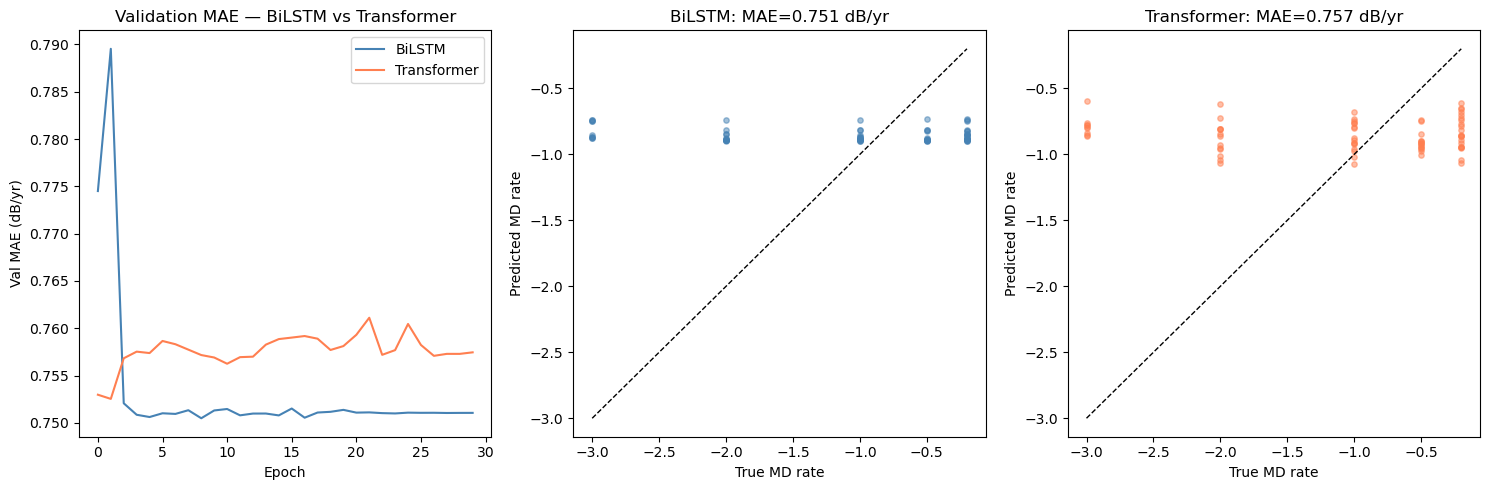


Final comparison:
  BiLSTM MAE:      0.7511 dB/yr
  Transformer MAE: 0.7575 dB/yr
  Winner (short sequences, n<10 visits): BiLSTM

→ Use BiLSTM in the GLAM architecture
→ Next: 08_nas_architecture_search.ipynb


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Training curves
axes[0].plot(lstm_maes, label="BiLSTM", color="steelblue")
axes[0].plot(trans_maes, label="Transformer", color="coral")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Val MAE (dB/yr)")
axes[0].set_title("Validation MAE — BiLSTM vs Transformer")
axes[0].legend()

# Scatter: BiLSTM predictions vs true
axes[1].scatter(lstm_targets, lstm_preds, alpha=0.5, s=15, color="steelblue")
lims = [min(lstm_targets.min(), lstm_preds.min()), max(lstm_targets.max(), lstm_preds.max())]
axes[1].plot(lims, lims, "k--", lw=1)
axes[1].set_xlabel("True MD rate"); axes[1].set_ylabel("Predicted MD rate")
axes[1].set_title(f"BiLSTM: MAE={lstm_maes[-1]:.3f} dB/yr")

# Scatter: Transformer
axes[2].scatter(trans_targets, trans_preds, alpha=0.5, s=15, color="coral")
axes[2].plot(lims, lims, "k--", lw=1)
axes[2].set_xlabel("True MD rate"); axes[2].set_ylabel("Predicted MD rate")
axes[2].set_title(f"Transformer: MAE={trans_maes[-1]:.3f} dB/yr")

plt.tight_layout()
plt.savefig("../reports/temporal_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nFinal comparison:")
print(f"  BiLSTM MAE:      {lstm_maes[-1]:.4f} dB/yr")
print(f"  Transformer MAE: {trans_maes[-1]:.4f} dB/yr")
winner = "BiLSTM" if lstm_maes[-1] < trans_maes[-1] else "Transformer"
print(f"  Winner (short sequences, n<10 visits): {winner}")
print(f"\n→ Use {winner} in the GLAM architecture")
print("→ Next: 08_nas_architecture_search.ipynb")